In [2]:
import pandas as pd

DATA_DIR = "/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment"

train_accel = pd.read_csv(f"{DATA_DIR}/train-accel.csv")
test_accel  = pd.read_csv(f"{DATA_DIR}/test-accel.csv")

train_gyro  = pd.read_csv(f"{DATA_DIR}/train-gyro.csv")
test_gyro   = pd.read_csv(f"{DATA_DIR}/test-gyro.csv")

train_label = pd.read_csv(f"{DATA_DIR}/train-label.csv")
test_label  = pd.read_csv(f"{DATA_DIR}/test-label.csv")

print(train_accel.shape)
print(train_gyro.shape)
print(train_label.shape)

(2428374, 7)
(2433673, 7)
(38015, 4)


In [3]:
print("Train PIDs:", train_label["pid"].nunique())
print("Test PIDs :", test_label["pid"].nunique())

print("\nTrain samples per PID")
print(train_label.groupby("pid").size().describe())

print("\nTest samples per PID")
print(test_label.groupby("pid").size().describe())

Train PIDs: 58
Test PIDs : 39

Train samples per PID
count      58.000000
mean      655.431034
std       251.141752
min       296.000000
25%       467.000000
50%       592.500000
75%       811.500000
max      1482.000000
dtype: float64

Test samples per PID
count      39.000000
mean     1012.128205
std       328.195960
min       158.000000
25%       846.500000
50%      1002.000000
75%      1139.000000
max      2014.000000
dtype: float64


In [4]:
print(train_label["workout"].value_counts(normalize=True).sort_index())

workout
0    0.089149
1    0.092674
2    0.094042
3    0.097251
4    0.094963
5    0.095410
6    0.094410
7    0.099829
8    0.242273
Name: proportion, dtype: float64


TRAIN PID count: 58
TEST PID count : 39


amag_mean                                  amag_std            \
              mean       std        min        max      mean       std   
dataset                                                                  
test     10.679083  0.298918   9.929282  11.272604  6.350684  1.458464   
train    10.727128  0.319637  10.193891  11.469322  6.327229  1.401446   

                             gmag_mean                                \
              min        max      mean       std       min       max   
dataset                                                                
test     3.050731  10.247022  0.874052  0.193699  0.607149  1.535752   
train    3.580395  11.786030  0.815496  0.204625  0.518846  1.640291   

         gmag_std                                
             mean       std       min       max  
dataset                                          
test     0.855929  0.267546  0.589261  1.923978  
train    0.820137  0.234454  0.499544  1.815961

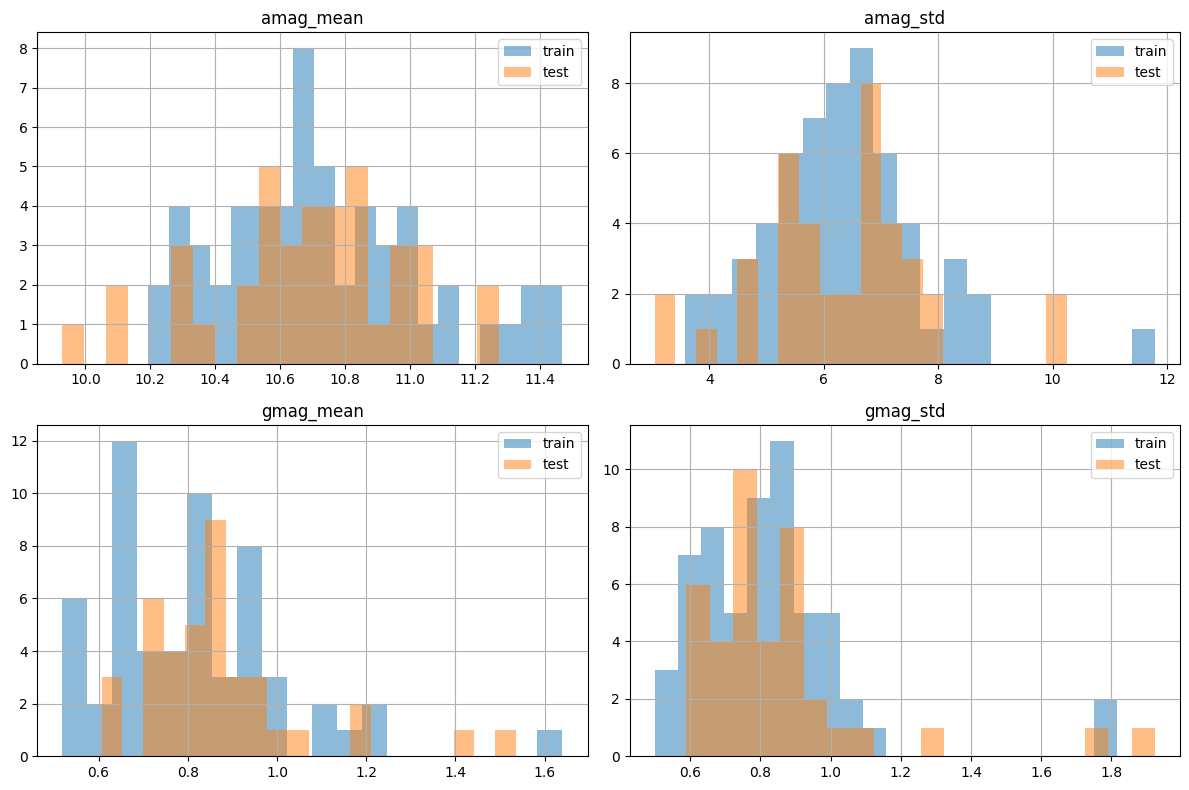

In [5]:
# ==========================================================
# PID-level distribution comparison
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def add_mag(df, prefix):

    df = df.copy()

    df[f'{prefix}mag'] = np.sqrt(
        df['x']**2 +
        df['y']**2 +
        df['z']**2
    )

    return df

train_accel2 = add_mag(train_accel, 'a')
test_accel2  = add_mag(test_accel, 'a')

train_gyro2 = add_mag(train_gyro, 'g')
test_gyro2  = add_mag(test_gyro, 'g')

train_pid = pd.DataFrame({
    'amag_mean':
        train_accel2.groupby('pid')['amag'].mean(),
    'amag_std':
        train_accel2.groupby('pid')['amag'].std(),
    'gmag_mean':
        train_gyro2.groupby('gmag').mean()
        if False else train_gyro2.groupby('pid')['gmag'].mean(),
    'gmag_std':
        train_gyro2.groupby('pid')['gmag'].std(),
})

train_pid['dataset'] = 'train'

test_pid = pd.DataFrame({
    'amag_mean':
        test_accel2.groupby('pid')['amag'].mean(),
    'amag_std':
        test_accel2.groupby('pid')['amag'].std(),
    'gmag_mean':
        test_gyro2.groupby('pid')['gmag'].mean(),
    'gmag_std':
        test_gyro2.groupby('pid')['gmag'].std(),
})

test_pid['dataset'] = 'test'

pid_stats = pd.concat([
    train_pid,
    test_pid
])

print("TRAIN PID count:", len(train_pid))
print("TEST PID count :", len(test_pid))

display(pid_stats.groupby('dataset').agg(['mean','std','min','max']))

fig, axs = plt.subplots(2,2, figsize=(12,8))

for ax, col in zip(
    axs.ravel(),
    ['amag_mean','amag_std','gmag_mean','gmag_std']
):

    train_pid[col].hist(
        bins=20,
        alpha=0.5,
        ax=ax,
        label='train'
    )

    test_pid[col].hist(
        bins=20,
        alpha=0.5,
        ax=ax,
        label='test'
    )

    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

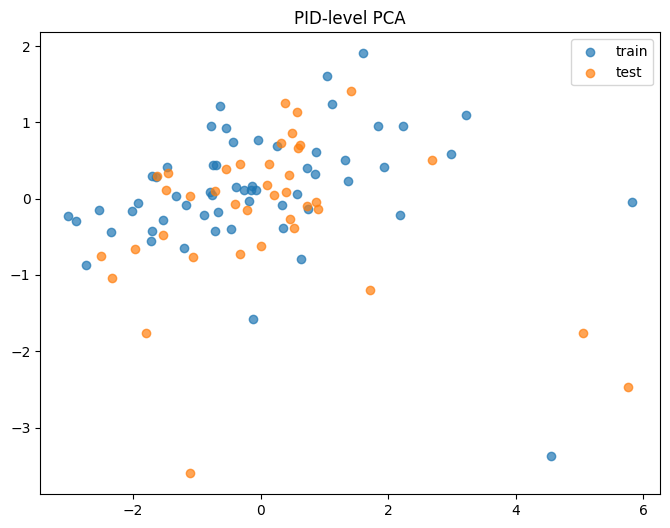

Explained variance: [0.72847757 0.19109605]


In [6]:
# ==========================================================
# PCA train vs test PID comparison
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pid_features = pd.concat([
    train_pid,
    test_pid
])

X_pid = pid_features[
    [
        'amag_mean',
        'amag_std',
        'gmag_mean',
        'gmag_std'
    ]
]

X_scaled = StandardScaler().fit_transform(X_pid)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

mask_train = pid_features['dataset'] == 'train'
mask_test  = pid_features['dataset'] == 'test'

plt.scatter(
    X_pca[mask_train,0],
    X_pca[mask_train,1],
    alpha=0.7,
    label='train'
)

plt.scatter(
    X_pca[mask_test,0],
    X_pca[mask_test,1],
    alpha=0.7,
    label='test'
)

plt.legend()
plt.title("PID-level PCA")
plt.show()

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

In [11]:
import numpy as np
import pandas as pd

for k in sorted(globals()):
    if any(word in k.lower() for word in [
        "oof",
        "pred",
        "blend",
        "prob",
        "group",
        "train",
        "test"
    ]):
        print(k)

mask_test
mask_train
test_accel
test_accel2
test_gyro
test_gyro2
test_label
test_pid
train_accel
train_accel2
train_gyro
train_gyro2
train_label
train_pid


In [12]:
print("numpy imported")
print("groups exists:", "groups" in globals())
print("y_train exists:", "y_train" in globals())
print("X_train exists:", "X_train" in globals())

numpy imported
groups exists: False
y_train exists: False
X_train exists: False


In [7]:
# ==========================================================
# Per-PID validation performance
# ==========================================================

from sklearn.metrics import balanced_accuracy_score

oof_pred = np.argmax(
    oof_blend_probs,
    axis=1
)

pid_scores = []

for pid in np.unique(groups):

    mask = groups == pid

    score = balanced_accuracy_score(
        y_train[mask],
        oof_pred[mask]
    )

    pid_scores.append([
        pid,
        score,
        mask.sum()
    ])

pid_scores = pd.DataFrame(
    pid_scores,
    columns=[
        'pid',
        'ba',
        'n_samples'
    ]
)

pid_scores = pid_scores.sort_values(
    'ba'
)

print("\nWorst 15 PIDs")
display(pid_scores.head(15))

print("\nBest 15 PIDs")
display(pid_scores.tail(15))

print("\nPID BA Summary")
display(
    pid_scores['ba'].describe()
)

plt.figure(figsize=(10,5))

plt.hist(
    pid_scores['ba'],
    bins=20
)

plt.title("Per-PID Balanced Accuracy")
plt.show()

NameError: name 'oof_blend_probs' is not defined

In [8]:
# show likely prediction variables

for k in sorted(globals().keys()):
    if any(x in k.lower() for x in [
        'oof',
        'pred',
        'blend',
        'prob'
    ]):
        print(k)

In [9]:
print("groups exists:", 'groups' in globals())
print("y_train exists:", 'y_train' in globals())

groups exists: False
y_train exists: False


In [10]:
print("OOF BA =", final_ba)

NameError: name 'final_ba' is not defined

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_train,
    final_oof_preds,
    normalize="true"
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("OOF Confusion Matrix")
plt.show()

ModuleNotFoundError: No module named 'seaborn'